In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Theme 1 — Revenue Timeline (Forecasting Foundation)

## Overview
Phân tích doanh thu theo thời gian nhằm phục vụ forecasting, tập trung vào xu hướng, tính chu kỳ và biên lợi nhuận.

---

## Layer 1 — Revenue Trend

**Biểu đồ:** Line Chart  
**Mô tả:**
- Doanh thu hàng ngày
- Kèm đường trung bình trượt 30 ngày (30-day moving average) để làm mượt dữ liệu (smoothing)

**Mục tiêu:**
- Nhận diện xu hướng ngắn hạn
- Giảm nhiễu (noise) trong dữ liệu



In [51]:
df_sales =  pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/sales.csv')
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales = df_sales.sort_values('Date')

df_sales['Revenue_SMA30'] = df_sales['Revenue'].rolling(window=30).mean()

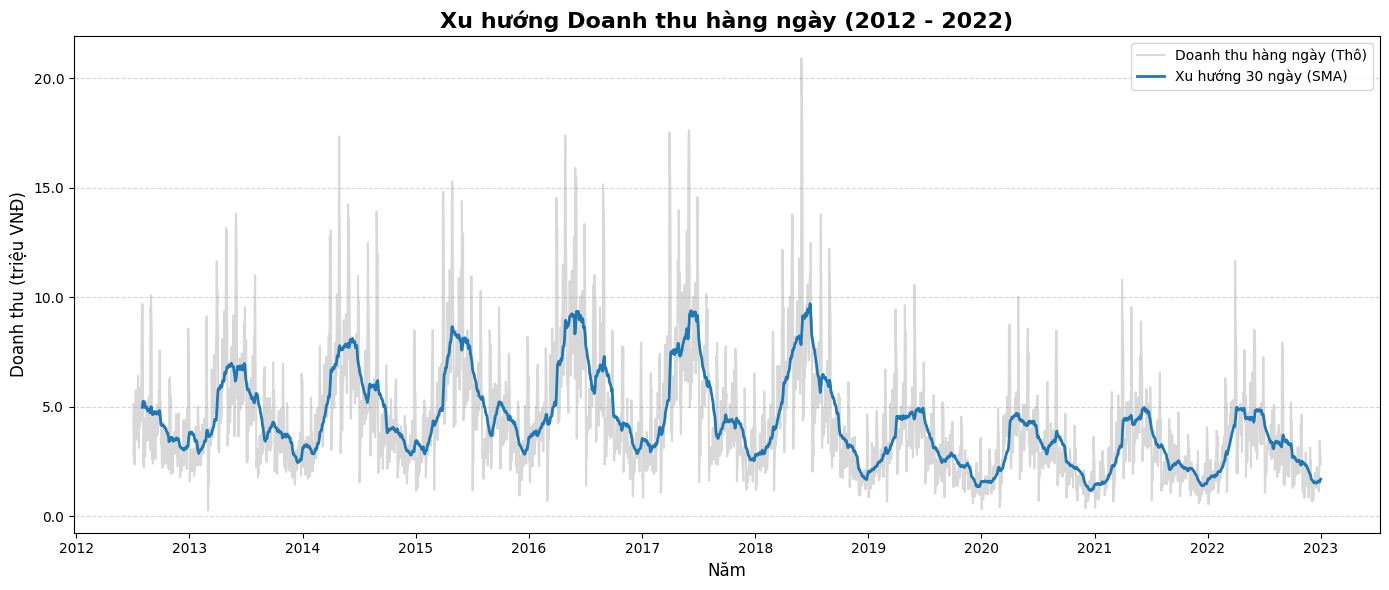

In [68]:
plt.figure(figsize=(14, 6))

plt.plot(df_sales['Date'], df_sales['Revenue'], 
         color='gray', alpha=0.3, 
         label='Doanh thu hàng ngày (Thô)')

plt.plot(df_sales['Date'], df_sales['Revenue_SMA30'], 
         color='#1f77b4', linewidth=2, 
         label='Xu hướng 30 ngày (SMA)')

ax = plt.gca()

# Trục X mỗi 1 năm
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Trục Y (triệu VNĐ)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}')
)

ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.title('Xu hướng Doanh thu hàng ngày (2012 - 2022)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Doanh thu (triệu VNĐ)', fontsize=12)

plt.legend()
plt.tight_layout()

fig_path = OUTPUT_DIR / 'daily_revenue_trend.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()

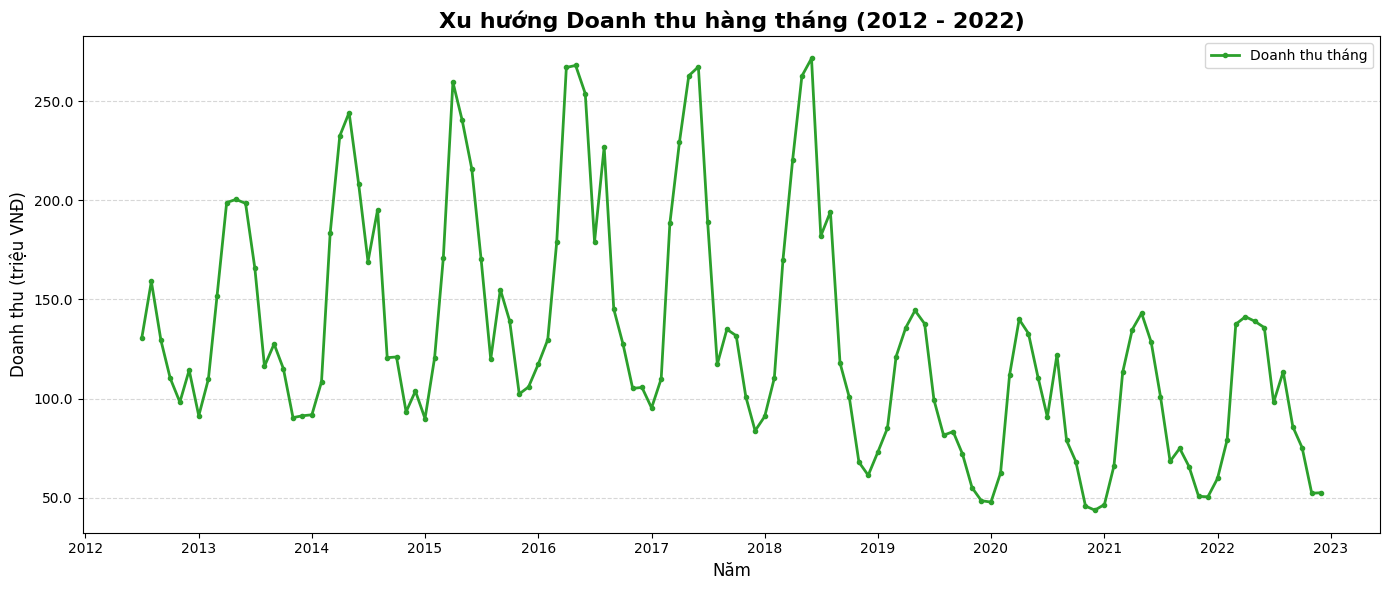

In [53]:
monthly_rev = df_sales.groupby(
    df_sales['Date'].dt.to_period('M')
)['Revenue'].sum().reset_index()

# Convert period -> timestamp
monthly_rev['Date'] = monthly_rev['Date'].dt.to_timestamp()

# 2. Plot
plt.figure(figsize=(14, 6))

plt.plot(monthly_rev['Date'], monthly_rev['Revenue'], 
         color='#2ca02c', linewidth=2,
         marker='o', markersize=3,
         label='Doanh thu tháng')

ax = plt.gca()

# 3. Trục X: mỗi 1 năm
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 4. Trục Y: scale về triệu
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}')
)

# 5. Grid: chỉ trục y
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# 6. Labels
plt.title('Xu hướng Doanh thu hàng tháng (2012 - 2022)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Doanh thu (triệu VNĐ)', fontsize=12)

plt.legend()
plt.tight_layout()

fig_path = OUTPUT_DIR / 'monthly_revenue_trend.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

# 7. Save + show
plt.show()

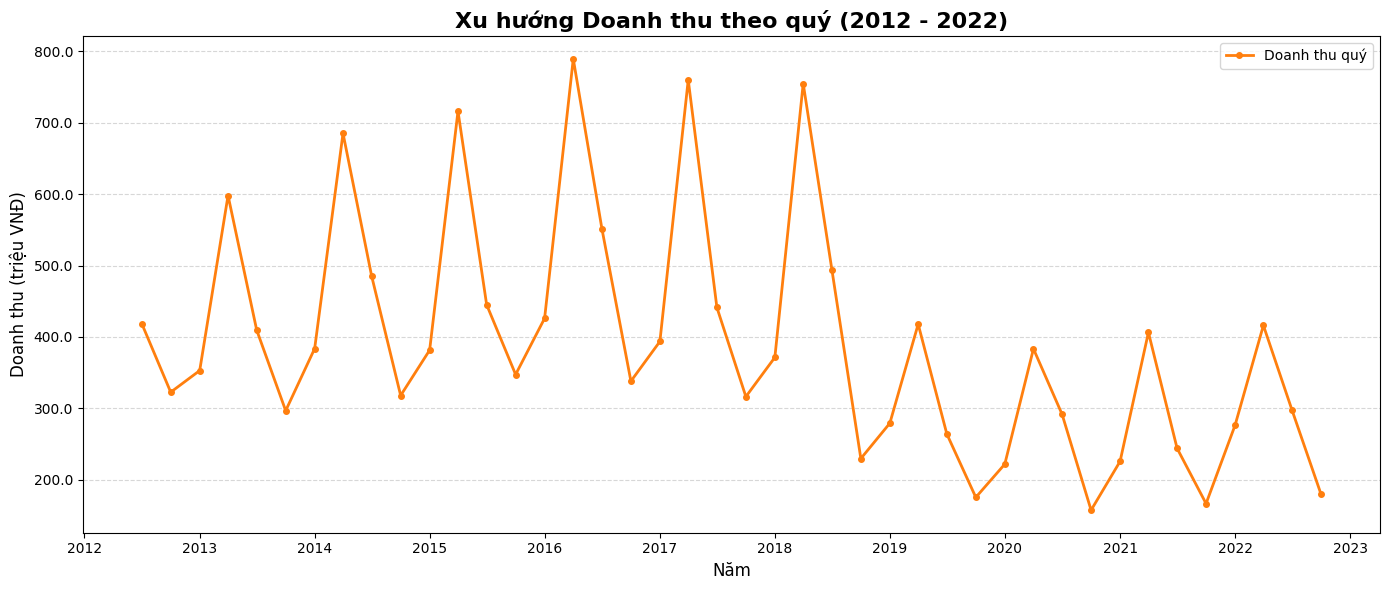

In [62]:
quarterly_rev = df_sales.groupby(
    df_sales['Date'].dt.to_period('Q')
)['Revenue'].sum().reset_index()

# Convert period -> timestamp
quarterly_rev['Date'] = quarterly_rev['Date'].dt.to_timestamp()

# Plot
plt.figure(figsize=(14, 6))

plt.plot(quarterly_rev['Date'], quarterly_rev['Revenue'], 
         color='#ff7f0e', linewidth=2,
         marker='o', markersize=4,
         label='Doanh thu quý')

ax = plt.gca()

# Trục X: mỗi 1 năm
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Trục Y: scale về triệu
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}')
)

# Grid: chỉ trục y
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# Labels
plt.title('Xu hướng Doanh thu theo quý (2012 - 2022)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Doanh thu (triệu VNĐ)', fontsize=12)

plt.legend()
plt.tight_layout()

fig_path = OUTPUT_DIR / 'quarterly_revenue_trend.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()

## Layer 2 — Gross Margin
- Bar chart theo quý  
- → Theo dõi expansion / contraction lợi nhuận  

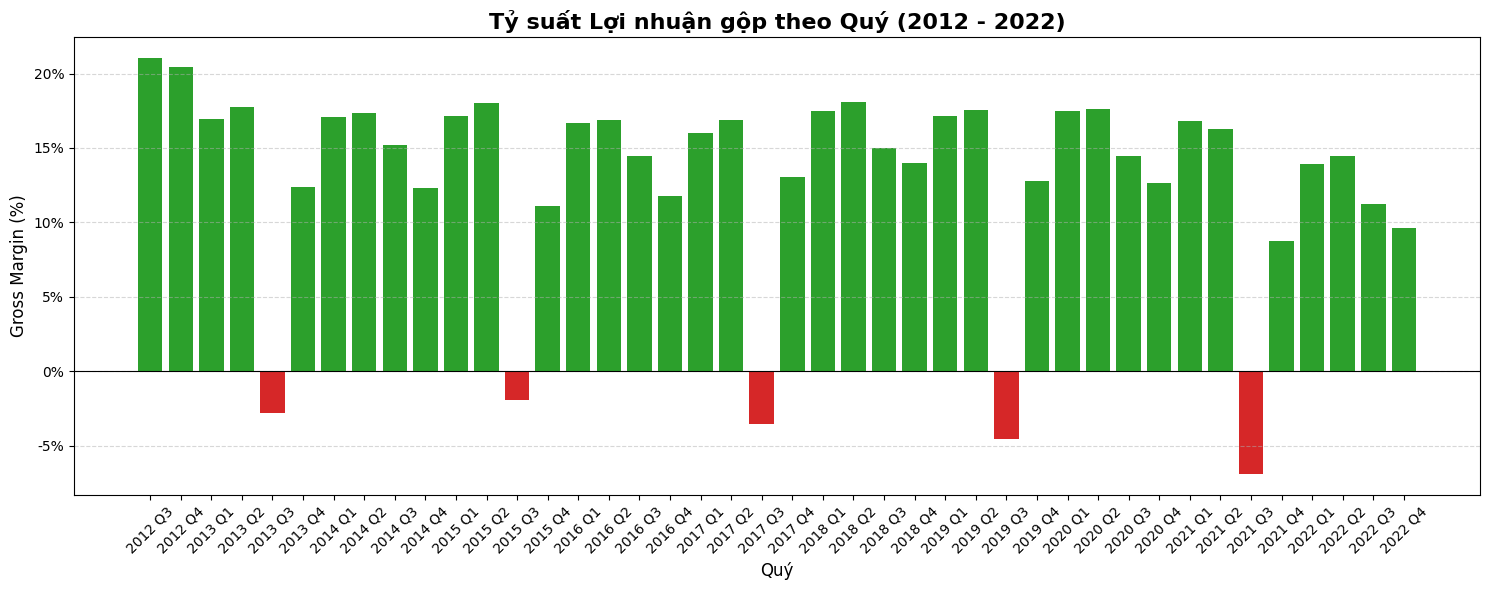

In [65]:
# 1. Resample theo quý
quarterly_data = df_sales.set_index('Date').resample('QE').agg({
    'Revenue': 'sum',
    'COGS': 'sum'
}).reset_index()

# 2. Tính Gross Margin (%)
quarterly_data['Gross_Margin'] = (
    (quarterly_data['Revenue'] - quarterly_data['COGS']) 
    / quarterly_data['Revenue']
) * 100

# 3. Tạo label quý
quarterly_data['Quarter'] = (
    quarterly_data['Date'].dt.year.astype(str) + 
    ' Q' + 
    quarterly_data['Date'].dt.quarter.astype(str)
)
# 4. Color mapping (semantic)
colors = ['#2ca02c' if x >= 0 else '#d62728' 
          for x in quarterly_data['Gross_Margin']]

# 5. Plot
plt.figure(figsize=(15, 6))

plt.bar(quarterly_data['Quarter'], 
        quarterly_data['Gross_Margin'], 
        color=colors)

# 6. Baseline
plt.axhline(0, color='black', linewidth=0.8)

ax = plt.gca()

# 7. Format %
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:.0f}%')
)

# 8. Grid: chỉ trục Y
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# 9. Labels
plt.title('Tỷ suất Lợi nhuận gộp theo Quý (2012 - 2022)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Quý', fontsize=12)
plt.ylabel('Gross Margin (%)', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
fig_path = OUTPUT_DIR / 'gross_margin_quarterly.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

# Theme 2 — Cohort Retention (Customer Health)

## Cohort Definition
- Nhóm khách hàng theo quý đăng ký  
- Dựa trên `signup_date` (customers.csv)

## Metrics
- Retention rate sau:
  - 3 tháng  
  - 6 tháng  
  - 12 tháng  

→ Đo lường tỷ lệ khách hàng quay lại mua hàng

In [81]:
df_customers = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/customers.csv')
df_orders = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/orders.csv')

# 2. Chuẩn hóa tên cột và ngày tháng
df_customers.columns = df_customers.columns.str.strip()
df_orders.columns = df_orders.columns.str.strip()

df_customers['signup_date'] = pd.to_datetime(df_customers['signup_date'])
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

# 2. Tìm ngày mua hàng đầu tiên của mỗi khách hàng
# Group theo customer_id và lấy giá trị min của order_date
first_orders = df_orders.groupby('customer_id')['order_date'].min().reset_index()
first_orders.columns = ['customer_id', 'first_order_date']

# 3. Xác định Cohort theo NĂM (Yearly Cohort)
first_orders['cohort_year'] = first_orders['first_order_date'].dt.year

# 4. Ghép lại vào bảng đơn hàng tổng để chuẩn bị cho bước sau
df_cohort = pd.merge(df_orders[['customer_id', 'order_date']], 
                            first_orders, 
                            on='customer_id')

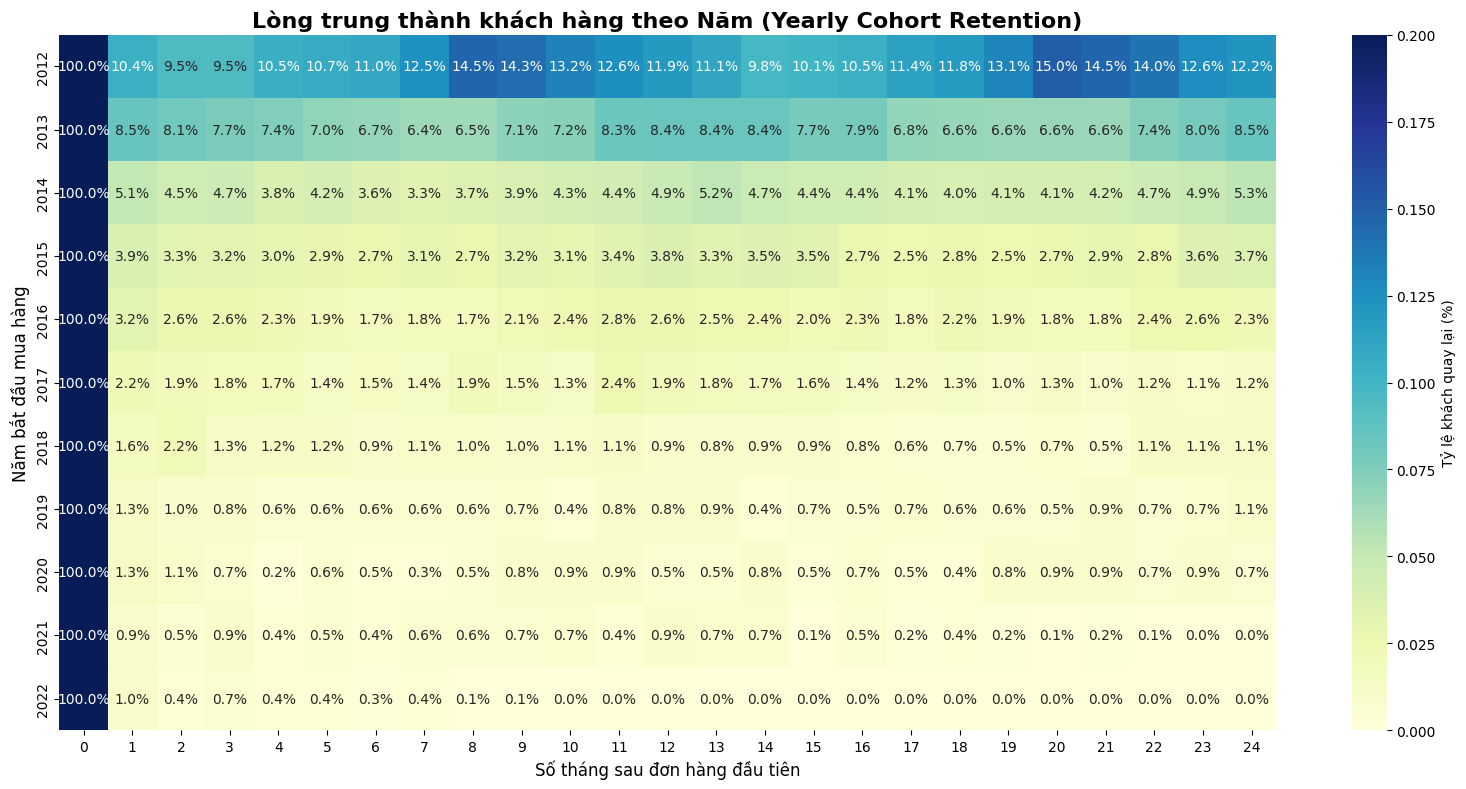

In [84]:
def get_month_index(row):
    return (row['order_date'].year - row['first_order_date'].year) * 12 + \
           (row['order_date'].month - row['first_order_date'].month)

# df_cohort là kết quả từ Bước 1 ở lượt chat trước
df_cohort['month_index'] = df_cohort.apply(get_month_index, axis=1)

# --- BƯỚC 3: LẬP MA TRẬN RETENTION ---
# 1. Tính số lượng khách hàng duy nhất cho mỗi năm (Mẫu số)
cohort_sizes = df_cohort.groupby('cohort_year')['customer_id'].nunique()

# 2. Đếm số khách quay lại theo từng tháng (Tử số)
retention_counts = df_cohort.groupby(['cohort_year', 'month_index'])['customer_id'].nunique().unstack(fill_value=0)

# 3. Tính tỷ lệ %
retention_matrix = retention_counts.divide(cohort_sizes, axis=0)

# --- BƯỚC 4: VẼ PLOT ĐÃ SỬA LỖI ---
plt.figure(figsize=(16, 8))

# Sửa lỗi hiển thị bằng vmax (0.2 = 20%) và fmt (định dạng %)
sns.heatmap(retention_matrix.iloc[:, :25], 
            annot=True, 
            fmt='.1%', 
            cmap='YlGnBu', 
            vmax=0.2, 
            cbar_kws={'label': 'Tỷ lệ khách quay lại (%)'})

plt.title('Lòng trung thành khách hàng theo Năm (Yearly Cohort Retention)', fontsize=16, fontweight='bold')
plt.xlabel('Số tháng sau đơn hàng đầu tiên', fontsize=12)
plt.ylabel('Năm bắt đầu mua hàng', fontsize=12)

plt.tight_layout()
plt.savefig('retention_yearly_fixed.png', dpi=300)
plt.show()